# Experiment: Gaussian HMM on four emission families

**Question:** how does a fitted Gaussian HMM behave when three hidden states generate Gaussian, heavy-tailed Student-t, standardized trimodal, or right-skewed Gamma observations?

There are **12 conditions**: 4 generating families × training sizes 1,000 / 5,000 / 20,000. The final settings use **20 independent replicates and 10 initializations per fit**, giving **2,400 attempted starts and 240 selected-fit evaluations**. Only a three-state Gaussian HMM is fitted.

All four emission families are matched to the same state means `(-2, 0, +2)` and variance `1`, so the cross-family comparison is primarily about emission **shape** rather than different first/second moments. Emission KL is evaluated by deterministic numerical quadrature. `MASTER_SEED = 42` makes the synthetic data and fit initializations reproducible.

**Metric definition:** `state_log_loss` is capped using the original float64-epsilon probability floor. The summary also reports the capped fraction and stored-zero-probability fraction. The summary and learning-curve outputs were refreshed from the 36 existing fitted models (3 replicates per condition), without retraining. Earlier saved outputs and the full-run settings above belong to a different execution; the refreshed summary describes the active 3-replicate run.


## Specifications

| Setting | Value |
|---|---|
| Genuine and fitted hidden states | 3, labeled 0, 1, 2 |
| Observations | One-dimensional |
| State means / variances for **all four families** | Means (-2, 0, +2); variance 1 |
| Initial / stationary probabilities | (1/3, 1/3, 1/3) |
| Self-transition probability | .90; moving to each other state .05 |
| Training lengths | 1,000 / 5,000 / 20,000 |
| Independent test length | 5,000 per family and replicate |
| Independent diagnostic density draws | 10,000 per true state, family, and replicate |
| Replicates / fitting starts | 20 / 10 |
| Fit limit | 300 EM updates; tolerance 0.000001 in log likelihood per observation |
| Chosen initialization | Highest finite training log likelihood |
| Model fitted | Gaussian-emission HMM, K=3 |
| Emission KL | Numerical quadrature of the true density against the aligned fitted Gaussian |

$$A=\begin{pmatrix}.90&.05&.05\\.05&.90&.05\\.05&.05&.90\end{pmatrix}.$$

For state means $\mu_k=(-2,0,2)$ and variance $1$:

| Family | State-conditional distribution |
|---|---|
| Gaussian | $X=\mu_k+Z$, $Z\sim N(0,1)$ |
| Student-t | $X=\mu_k+\sqrt{(2.5-2)/2.5}\,T$, $T\sim t_{2.5}$ |
| Skewed Gamma | Shifted/scaled Gamma with shape `GAMMA_SHAPE`; mean $\mu_k$ and variance 1 |
| Trimodal | Three-Gaussian mixture whose raw component template is affinely standardized to mean $\mu_k$ and variance 1 |

## Imports and Settings

In [ ]:
from pathlib import Path
import hashlib
import json
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, stats
from scipy.special import logsumexp
from IPython.display import display

project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src/synthetic_data_generation/markov_process_generation.py").exists())
sys.path.insert(0, str(project_root / "src"))
from synthetic_data_generation.markov_process_generation import (
    GaussianEmissionGenerator, StudentTEmissionGenerator, MultimodalEmissionGenerator,
    GammaEmissionGenerator,
)
from flexible_emission_hmm import HMM, GaussianEmission, BaumWelchTrainer
from model_evaluation.synthetic import SyntheticEvaluator
from model_evaluation.synthetic.state_alignment import STATE_LOG_LOSS_FLOOR

MASTER_SEED = 42
TRAIN_SIZES = [1_000, 5_000, 20_000]
N_TEST = 5_000
N_DENSITY = 10_000                    
N_REPLICATES = 20                  
N_STARTS = 10
MAX_ITER = 300
TOL_PER_OBSERVATION = 1e-6
QUAD_EPSABS = 1e-9
QUAD_EPSREL = 1e-9
QUAD_LIMIT = 500

MEANS = np.array([-2., 0., 2.])
STATES = np.arange(3)
INITIAL = np.full(3, 1 / 3)
TRANSITIONS = np.full((3, 3), .05)
np.fill_diagonal(TRANSITIONS, .9)
VARIANCE = 1.0
T_DF = 2.5
GAMMA_SHAPE = 4

# Raw templates define the trimodal shape. They are standardized below so each
# state's final mixture has the same target mean and variance as the other families.
MIXTURE_WEIGHTS = np.array([[.25, .50, .25], [.20, .45, .35], [.35, .40, .25]])
RAW_MIXTURE_MEANS = np.array([[-3.4, -2.1, -.6], [-1.4, .2, 1.7], [.5, 2.1, 3.5]])
RAW_MIXTURE_STDS = np.array([[.22, .35, .28], [.30, .24, .42], [.38, .25, .32]])

raw_mixture_means = np.sum(MIXTURE_WEIGHTS * RAW_MIXTURE_MEANS, axis=1)
raw_mixture_variances = np.sum(
    MIXTURE_WEIGHTS * (RAW_MIXTURE_STDS**2 +
    (RAW_MIXTURE_MEANS - raw_mixture_means[:, None])**2), axis=1)
raw_mixture_stds = np.sqrt(raw_mixture_variances)

target_std = np.sqrt(VARIANCE)
MIXTURE_MEANS = ((RAW_MIXTURE_MEANS - raw_mixture_means[:, None]) /
                 raw_mixture_stds[:, None] * target_std + MEANS[:, None])
MIXTURE_STDS = RAW_MIXTURE_STDS / raw_mixture_stds[:, None] * target_std

FAMILIES = ["Gaussian", "Student-t", "Trimodal", "Skewed Gamma"]
COLORS = {"Gaussian": "#4477AA", "Student-t": "#CC6677", "Trimodal": "#228833", "Skewed Gamma": "#AA7733"}
TRUE_MEANS = {family: MEANS.copy() for family in FAMILIES}
TRUE_VARIANCES = {family: np.full(3, VARIANCE) for family in FAMILIES}

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110, "axes.grid": True, "grid.alpha": .18})
assert N_REPLICATES >= 1 and N_STARTS >= 1 and T_DF > 2
np.testing.assert_allclose(INITIAL @ TRANSITIONS, INITIAL)

# Verify the standardized trimodal parameters analytically.
trimodal_means = np.sum(MIXTURE_WEIGHTS * MIXTURE_MEANS, axis=1)
trimodal_variances = np.sum(
    MIXTURE_WEIGHTS * (MIXTURE_STDS**2 + (MIXTURE_MEANS - trimodal_means[:, None])**2), axis=1)
np.testing.assert_allclose(trimodal_means, MEANS, atol=1e-12)
np.testing.assert_allclose(trimodal_variances, VARIANCE, atol=1e-12)

n_conditions = len(FAMILIES) * len(TRAIN_SIZES)
print(f"{n_conditions} conditions × {N_REPLICATES} replicates × {N_STARTS} starts = "
      f"{n_conditions * N_REPLICATES * N_STARTS} fits")
specifications = pd.DataFrame([
    {"family": family, "state": k, "mean": TRUE_MEANS[family][k], "variance": TRUE_VARIANCES[family][k]}
    for family in FAMILIES for k in STATES])
display(specifications.round(4))

display(pd.DataFrame({
    "state": STATES,
    "weights": [row.tolist() for row in MIXTURE_WEIGHTS],
    "standardized_component_means": [np.round(row, 4).tolist() for row in MIXTURE_MEANS],
    "standardized_component_stds": [np.round(row, 4).tolist() for row in MIXTURE_STDS],
}))


12 conditions × 20 replicates × 10 starts = 2400 fits


,family,state,mean,variance
0,Gaussian,0,-2.0,1.0
1,Gaussian,1,0.0,1.0
2,Gaussian,2,2.0,1.0
3,Student-t,0,-2.0,1.0
4,Student-t,1,0.0,1.0
5,Student-t,2,2.0,1.0
6,Trimodal,0,-2.0,1.0
7,Trimodal,1,0.0,1.0
8,Trimodal,2,2.0,1.0
9,Skewed Gamma,0,-2.0,1.0


,state,weights,standardized_component_means,standardized_component_stds
0,0,"[0.25, 0.5, 0.25]","[-3.3018, -2.0482, -0.6018]","[0.2121, 0.3375, 0.27]"
1,1,"[0.2, 0.45, 0.35]","[-1.546, -0.1756, 1.1092]","[0.257, 0.2056, 0.3597]"
2,2,"[0.35, 0.4, 0.25]","[0.8429, 2.1748, 3.3403]","[0.3163, 0.2081, 0.2664]"


## Generate Synthetic Data
`datasets[(replicate, family)]` contains `train`, `test`, and `density` DataFrames. Columns are `time` (or `draw` for independent density draws), `state`, `component`, and `x`. Component is -1 outside the mixture family. The `density` rows are independent per-state draws. 

In [2]:
def seed_for(*parts):
    payload = json.dumps([MASTER_SEED, *parts]).encode()
    return int.from_bytes(hashlib.sha256(payload).digest()[:4], "little")


def make_generator(family, seed, length):
    parameters = []
    for k in STATES:
        mean, std = TRUE_MEANS[family][k], np.sqrt(TRUE_VARIANCES[family][k])
        if family == "Gaussian":
            cls, values = GaussianEmissionGenerator, [mean, std]
        elif family == "Student-t":
            cls, values = StudentTEmissionGenerator, [mean, std, T_DF]
        elif family == "Trimodal":
            cls, values = MultimodalEmissionGenerator, [
                mean, std, MIXTURE_WEIGHTS[k], MIXTURE_MEANS[k], MIXTURE_STDS[k]
            ]
        elif family == "Skewed Gamma":
            cls, values = GammaEmissionGenerator, [mean, std, GAMMA_SHAPE]
        else:
            raise ValueError(f"Unknown family: {family}")
        parameters.append(values)
    return cls(parameters, STATES, INITIAL, TRANSITIONS, length, random_state=seed)


def true_log_density(family, state, values):
    x = np.asarray(values).reshape(-1)
    mean, std = TRUE_MEANS[family][state], np.sqrt(TRUE_VARIANCES[family][state])
    if family == "Gaussian":
        return stats.norm.logpdf(x, mean, std)
    if family == "Student-t":
        return stats.t.logpdf(x, T_DF, loc=mean, scale=std * np.sqrt((T_DF - 2) / T_DF))
    if family == "Skewed Gamma":
        return stats.gamma.logpdf(
            x, GAMMA_SHAPE,
            loc=mean - std * np.sqrt(GAMMA_SHAPE),
            scale=std / np.sqrt(GAMMA_SHAPE),
        )
    if family == "Trimodal":
        return logsumexp(
            np.log(MIXTURE_WEIGHTS[state])[None, :] +
            stats.norm.logpdf(x[:, None], MIXTURE_MEANS[state], MIXTURE_STDS[state]),
            axis=1,
        )
    raise ValueError(f"Unknown family: {family}")


def true_support_lower(family, state):
    if family == "Skewed Gamma":
        mean = TRUE_MEANS[family][state]
        std = np.sqrt(TRUE_VARIANCES[family][state])
        return mean - std * np.sqrt(GAMMA_SHAPE)
    return -np.inf


def kl_true_to_gaussian(family, state, gaussian_mean, gaussian_variance):
    """Compute KL(p_true || N(gaussian_mean, gaussian_variance)) by quadrature."""
    if not np.isfinite(gaussian_mean) or not np.isfinite(gaussian_variance) or gaussian_variance <= 0:
        return np.inf, np.inf

    gaussian_std = np.sqrt(gaussian_variance)

    def integrand(x):
        log_p = float(true_log_density(family, state, [x])[0])
        if log_p == -np.inf:
            return 0.0
        p = np.exp(log_p)
        log_q = stats.norm.logpdf(x, loc=gaussian_mean, scale=gaussian_std)
        return p * (log_p - log_q)

    lower = true_support_lower(family, state)
    value, error = integrate.quad(
        integrand, lower, np.inf,
        epsabs=QUAD_EPSABS, epsrel=QUAD_EPSREL, limit=QUAD_LIMIT,
    )
    return float(value), float(error)


# The moment-matched Gaussian is the KL-optimal Gaussian for KL(p || q).
# This is the unavoidable Gaussian-family mismatch before any HMM state-recovery error.
KL_FLOOR_BY_STATE = {}
for family in FAMILIES:
    KL_FLOOR_BY_STATE[family] = np.array([
        kl_true_to_gaussian(
            family, k, TRUE_MEANS[family][k], TRUE_VARIANCES[family][k]
        )[0]
        for k in STATES
    ])
KL_FLOOR = {family: float(values.mean()) for family, values in KL_FLOOR_BY_STATE.items()}


def generate_datasets():
    datasets, coverage_rows = {}, []
    for replicate in range(N_REPLICATES):
        paths = {
            split: make_generator("Gaussian", seed_for("path", replicate, split), length).sample_state_path()
            for split, length in [("train", max(TRAIN_SIZES)), ("test", N_TEST)]
        }
        for family in FAMILIES:
            data = {}
            for split, path in paths.items():
                generator = make_generator(
                    family, seed_for("observations", replicate, family, split), len(path)
                )
                X, components = generator.sample_emissions(path, return_components=True)
                data[split] = pd.DataFrame({
                    "time": np.arange(len(path)), "state": path.copy(),
                    "component": components, "x": X[:, 0],
                })
                for length in (TRAIN_SIZES if split == "train" else [N_TEST]):
                    labels = path[:length]
                    transitions = np.zeros((3, 3), dtype=int)
                    np.add.at(transitions, (labels[:-1], labels[1:]), 1)
                    coverage_rows.append({
                        "family": family, "replicate": replicate, "split": split,
                        "n": length, "state_visits": np.bincount(labels, minlength=3).tolist(),
                        "transition_counts": transitions.tolist(),
                        "switches": int((labels[1:] != labels[:-1]).sum()),
                    })

            # Independent per-state draws are retained only for descriptive plots/moment checks.
            labels = np.repeat(STATES, N_DENSITY)
            generator = make_generator(family, seed_for("density", replicate, family), len(labels))
            X, components = generator.sample_emissions(labels, return_components=True)
            data["density"] = pd.DataFrame({
                "draw": np.tile(np.arange(N_DENSITY), len(STATES)),
                "state": labels, "component": components, "x": X[:, 0],
            })
            datasets[replicate, family] = data
    return datasets, pd.DataFrame(coverage_rows)


def sha256_if_exists(path):
    path = Path(path)
    return hashlib.sha256(path.read_bytes()).hexdigest() if path.exists() and path.is_file() else None


datasets, coverage = generate_datasets()
manifest = {
    "master_seed": MASTER_SEED, "families": FAMILIES, "states": STATES.tolist(),
    "means": {f: v.tolist() for f, v in TRUE_MEANS.items()},
    "variances": {f: v.tolist() for f, v in TRUE_VARIANCES.items()},
    "initial": INITIAL.tolist(), "transitions": TRANSITIONS.tolist(), "student_t_df": T_DF,
    "gamma_shape": GAMMA_SHAPE,
    "mixture_weights": MIXTURE_WEIGHTS.tolist(),
    "raw_mixture_means": RAW_MIXTURE_MEANS.tolist(),
    "raw_mixture_component_stds": RAW_MIXTURE_STDS.tolist(),
    "standardized_mixture_means": MIXTURE_MEANS.tolist(),
    "standardized_mixture_component_stds": MIXTURE_STDS.tolist(),
    "train_sizes": TRAIN_SIZES, "test_size": N_TEST,
    "diagnostic_density_draws_per_state": N_DENSITY,
    "replicates": N_REPLICATES, "starts": N_STARTS, "max_iter": MAX_ITER,
    "tol_per_observation": TOL_PER_OBSERVATION,
    "quadrature": {"epsabs": QUAD_EPSABS, "epsrel": QUAD_EPSREL, "limit": QUAD_LIMIT},
    "best_gaussian_kl_floor": KL_FLOOR,
    "numpy_version": np.__version__,
    "source_hashes": {
        "generator": sha256_if_exists(project_root / "src/synthetic_data_generation/markov_process_generation.py"),
        "synthetic_evaluator": sha256_if_exists(project_root / "src/model_evaluation/synthetic/state_alignment.py"),
    },
    "seed_recipe": "first 4 SHA256 bytes, little endian, of json.dumps([master_seed, *parts])",
    "state_log_loss_floor": float(STATE_LOG_LOSS_FLOOR),
    "state_log_loss_definition": "Mean negative log(max(true-state posterior, float64 epsilon)); capped",
    "selection": "highest finite training LL; test data and labels never select a start",
}
print(f"Generated {len(datasets)} family/replicate datasets in memory.")
print("Best-Gaussian KL floors (nats):", {k: round(v, 6) for k, v in KL_FLOOR.items()})
train_df = datasets[(0, "Trimodal")]["train"].iloc[:1_000].copy()
display(train_df.head())


Generated 80 family/replicate datasets in memory.
Best-Gaussian KL floors (nats): {'Gaussian': 0.0, 'Student-t': 0.375897, 'Trimodal': 0.294603, 'Skewed Gamma': 0.088679}


,time,state,component,x
0,0,2,1,2.287336
1,1,2,0,0.853907
2,2,2,1,1.914327
3,3,2,0,0.875296
4,4,2,1,2.186129


### Check the data and density formulas

In [3]:
# Check each true density integrates to one and has the intended first two moments.
for family in FAMILIES:
    for k in STATES:
        mean, variance = TRUE_MEANS[family][k], TRUE_VARIANCES[family][k]
        f = lambda x: float(np.exp(true_log_density(family, k, [x])[0]))
        lower = true_support_lower(family, k)
        mass = integrate.quad(f, lower, np.inf, epsabs=1e-7, limit=QUAD_LIMIT)[0]
        actual_mean = integrate.quad(lambda x: x * f(x), lower, np.inf,
                                     epsabs=1e-7, limit=QUAD_LIMIT)[0]
        actual_variance = integrate.quad(lambda x: (x - mean)**2 * f(x), lower, np.inf,
                                         epsabs=1e-7, limit=QUAD_LIMIT)[0]
        np.testing.assert_allclose(
            [mass, actual_mean, actual_variance], [1., mean, variance], atol=2e-6
        )

# Verify deterministic seed replay, dimensions, common latent paths, and state coverage.
replayed, replayed_coverage = generate_datasets()
moment_rows = []
for (replicate, family), data in datasets.items():
    for split, expected in [("train", max(TRAIN_SIZES)), ("test", N_TEST), ("density", 3 * N_DENSITY)]:
        frame = data[split]
        assert frame.shape == (expected, 4) and np.isfinite(frame.x).all()
        pd.testing.assert_frame_equal(frame, replayed[replicate, family][split])
        if split != "density":
            np.testing.assert_array_equal(frame.state, datasets[replicate, "Gaussian"][split].state)
    for length in TRAIN_SIZES:
        assert data["train"].iloc[:length].state.nunique() == 3, "Cannot align an absent training state"
    for k, frame in data["density"].groupby("state"):
        moment_rows.append({
            "family": family, "replicate": replicate, "state": k,
            "sample_mean": frame.x.mean(), "target_mean": TRUE_MEANS[family][k],
            "sample_variance": frame.x.var(ddof=1), "target_variance": TRUE_VARIANCES[family][k],
        })

pd.testing.assert_frame_equal(coverage, replayed_coverage)
del replayed, replayed_coverage
moment_checks = pd.DataFrame(moment_rows)

# Quadrature KL should be essentially zero for a true Gaussian versus its moment-matched Gaussian.
assert abs(KL_FLOOR["Gaussian"]) < 1e-8
assert all(np.isfinite(list(KL_FLOOR.values())))

print("Verified density moments, dimensions, shared paths, state coverage, exact seed replay, and KL quadrature.")
display(coverage[(coverage.family == "Gaussian") & (coverage.split == "train")]
        [["replicate", "n", "state_visits", "switches"]].head(12))
display(moment_checks.groupby(["family", "state"])
        [["sample_mean", "target_mean", "sample_variance", "target_variance"]].mean().round(3))
display(pd.DataFrame({
    "family": FAMILIES,
    "best_gaussian_kl_floor": [KL_FLOOR[f] for f in FAMILIES],
}).set_index("family").round(6))


Verified density moments, dimensions, shared paths, state coverage, exact seed replay, and KL quadrature.


,replicate,n,state_visits,switches
0,0,1000,"[368, 293, 339]",91
1,0,5000,"[1822, 1536, 1642]",501
2,0,20000,"[6943, 5975, 7082]",1985
16,1,1000,"[433, 291, 276]",97
17,1,5000,"[1733, 1592, 1675]",490
18,1,20000,"[6971, 6710, 6319]",2008
32,2,1000,"[356, 347, 297]",109
33,2,5000,"[1746, 1620, 1634]",493
34,2,20000,"[6681, 6726, 6593]",2000
48,3,1000,"[403, 305, 292]",109


sample_mean  target_mean  sample_variance  target_variance
family       state                                                            
Gaussian     0           -1.996         -2.0            0.994              1.0
             1            0.002          0.0            0.997              1.0
             2            2.002          2.0            1.002              1.0
Skewed Gamma 0           -1.998         -2.0            1.003              1.0
             1            0.000          0.0            1.004              1.0
             2            1.997          2.0            0.996              1.0
Student-t    0           -2.000         -2.0            0.842              1.0
             1            0.004          0.0            0.919              1.0
             2            2.002          2.0            0.878              1.0
Trimodal     0           -2.001         -2.0            1.002              1.0
             1           -0.000          0.0            0.998              1.0
             2            1.997          2.0            0.999              1.0

,best_gaussian_kl_floor
family,
Gaussian,0.000000
Student-t,0.375897
Trimodal,0.294603
Skewed Gamma,0.088679


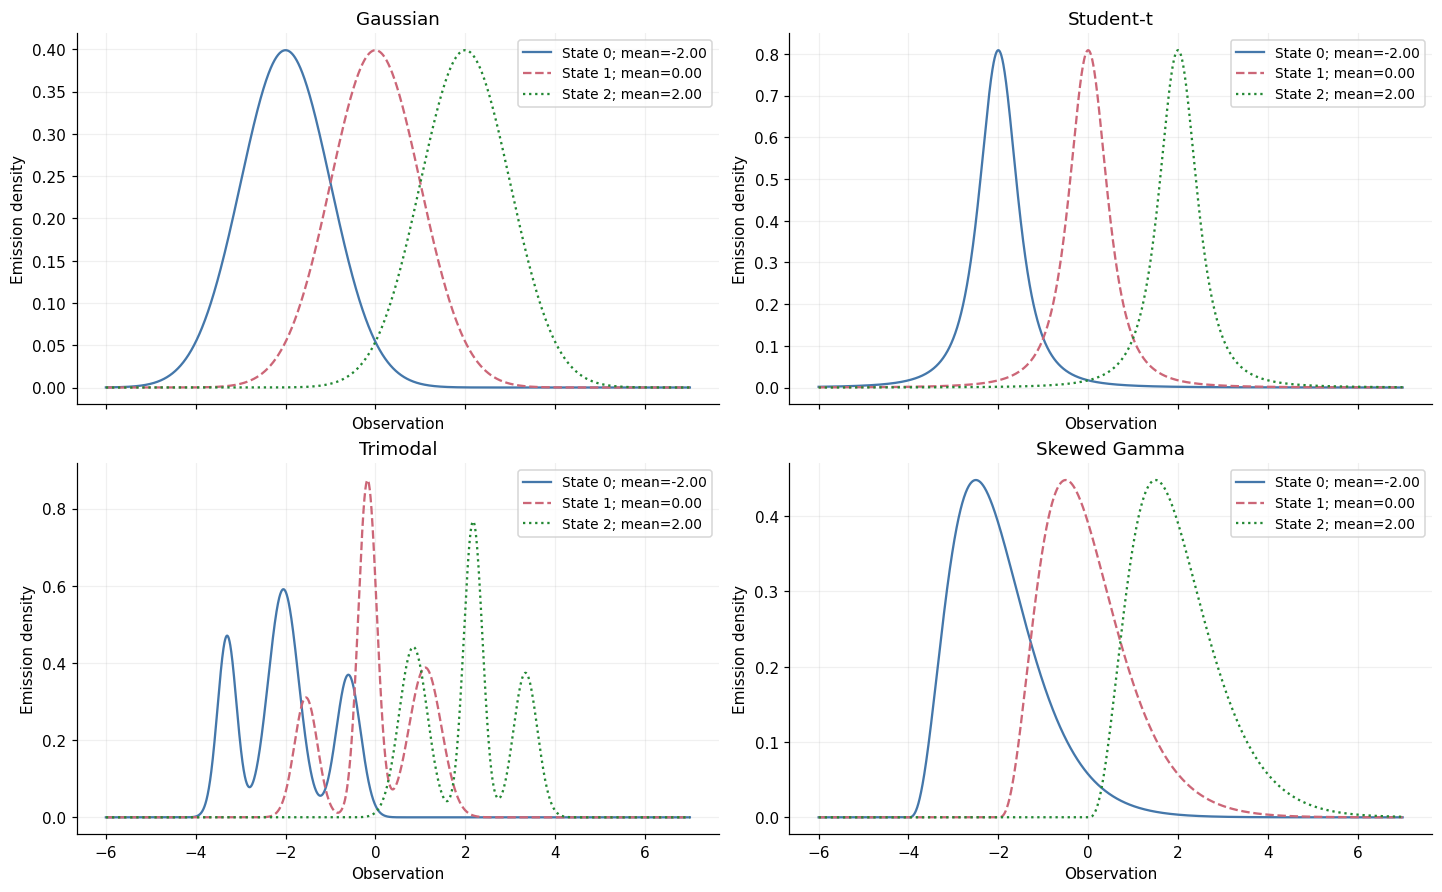

,minimum,q01,median,q99,maximum
family,,,,,
Gaussian,-3.645,-2.362,0.035,2.278,3.666
Student-t,-27.810,-2.503,-0.001,2.404,15.329
Trimodal,-2.402,-1.976,-0.094,1.794,2.372
Skewed Gamma,-1.932,-1.584,-0.166,3.036,5.221


In [4]:
x = np.linspace(-6, 7, 2400)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=False, layout="constrained")
state_colors = ["#4477AA", "#CC6677", "#228833"]
for ax, family in zip(axes.flat, FAMILIES):
    for k in STATES:
        ax.plot(x, np.exp(true_log_density(family, k, x)), color=state_colors[k],
                linestyle=["-", "--", ":"][k], label=f"State {k}; mean={TRUE_MEANS[family][k]:.2f}")
    ax.set(title=family, xlabel="Observation", ylabel="Emission density")
for ax in axes.flat:
    ax.legend(fontsize=9)
plt.show()
# Independent density draws expose tail extremes without clipping or rescaling.
tail_rows = []
for family in FAMILIES:
    values = datasets[0, family]["density"].query("state == 1").x
    tail_rows.append({"family": family, "minimum": values.min(), "q01": values.quantile(.01),
                      "median": values.median(), "q99": values.quantile(.99), "maximum": values.max()})
display(pd.DataFrame(tail_rows).set_index("family").round(3))

## Synthetic observations with true regimes: 20,000 training points

The plots use the existing **training sequence, replicate 0**, for each emission family. Every observation is colored and marked by its **true generating state**, not a fitted prediction. The left column includes all 20,000 points without clipping or subsampling; the right column shows the first 500 observations in detail. The bottom row shows the shared true state path.

Observation axes use separate vertical scales to retain the full range of each distribution, including extreme Student-t values. Change `PLOT_REPLICATE`, `PLOT_ZOOM_START`, or `PLOT_ZOOM_LENGTH` below to inspect another existing replicate or window. This cell only plots existing data and never fits a model or regenerates data.


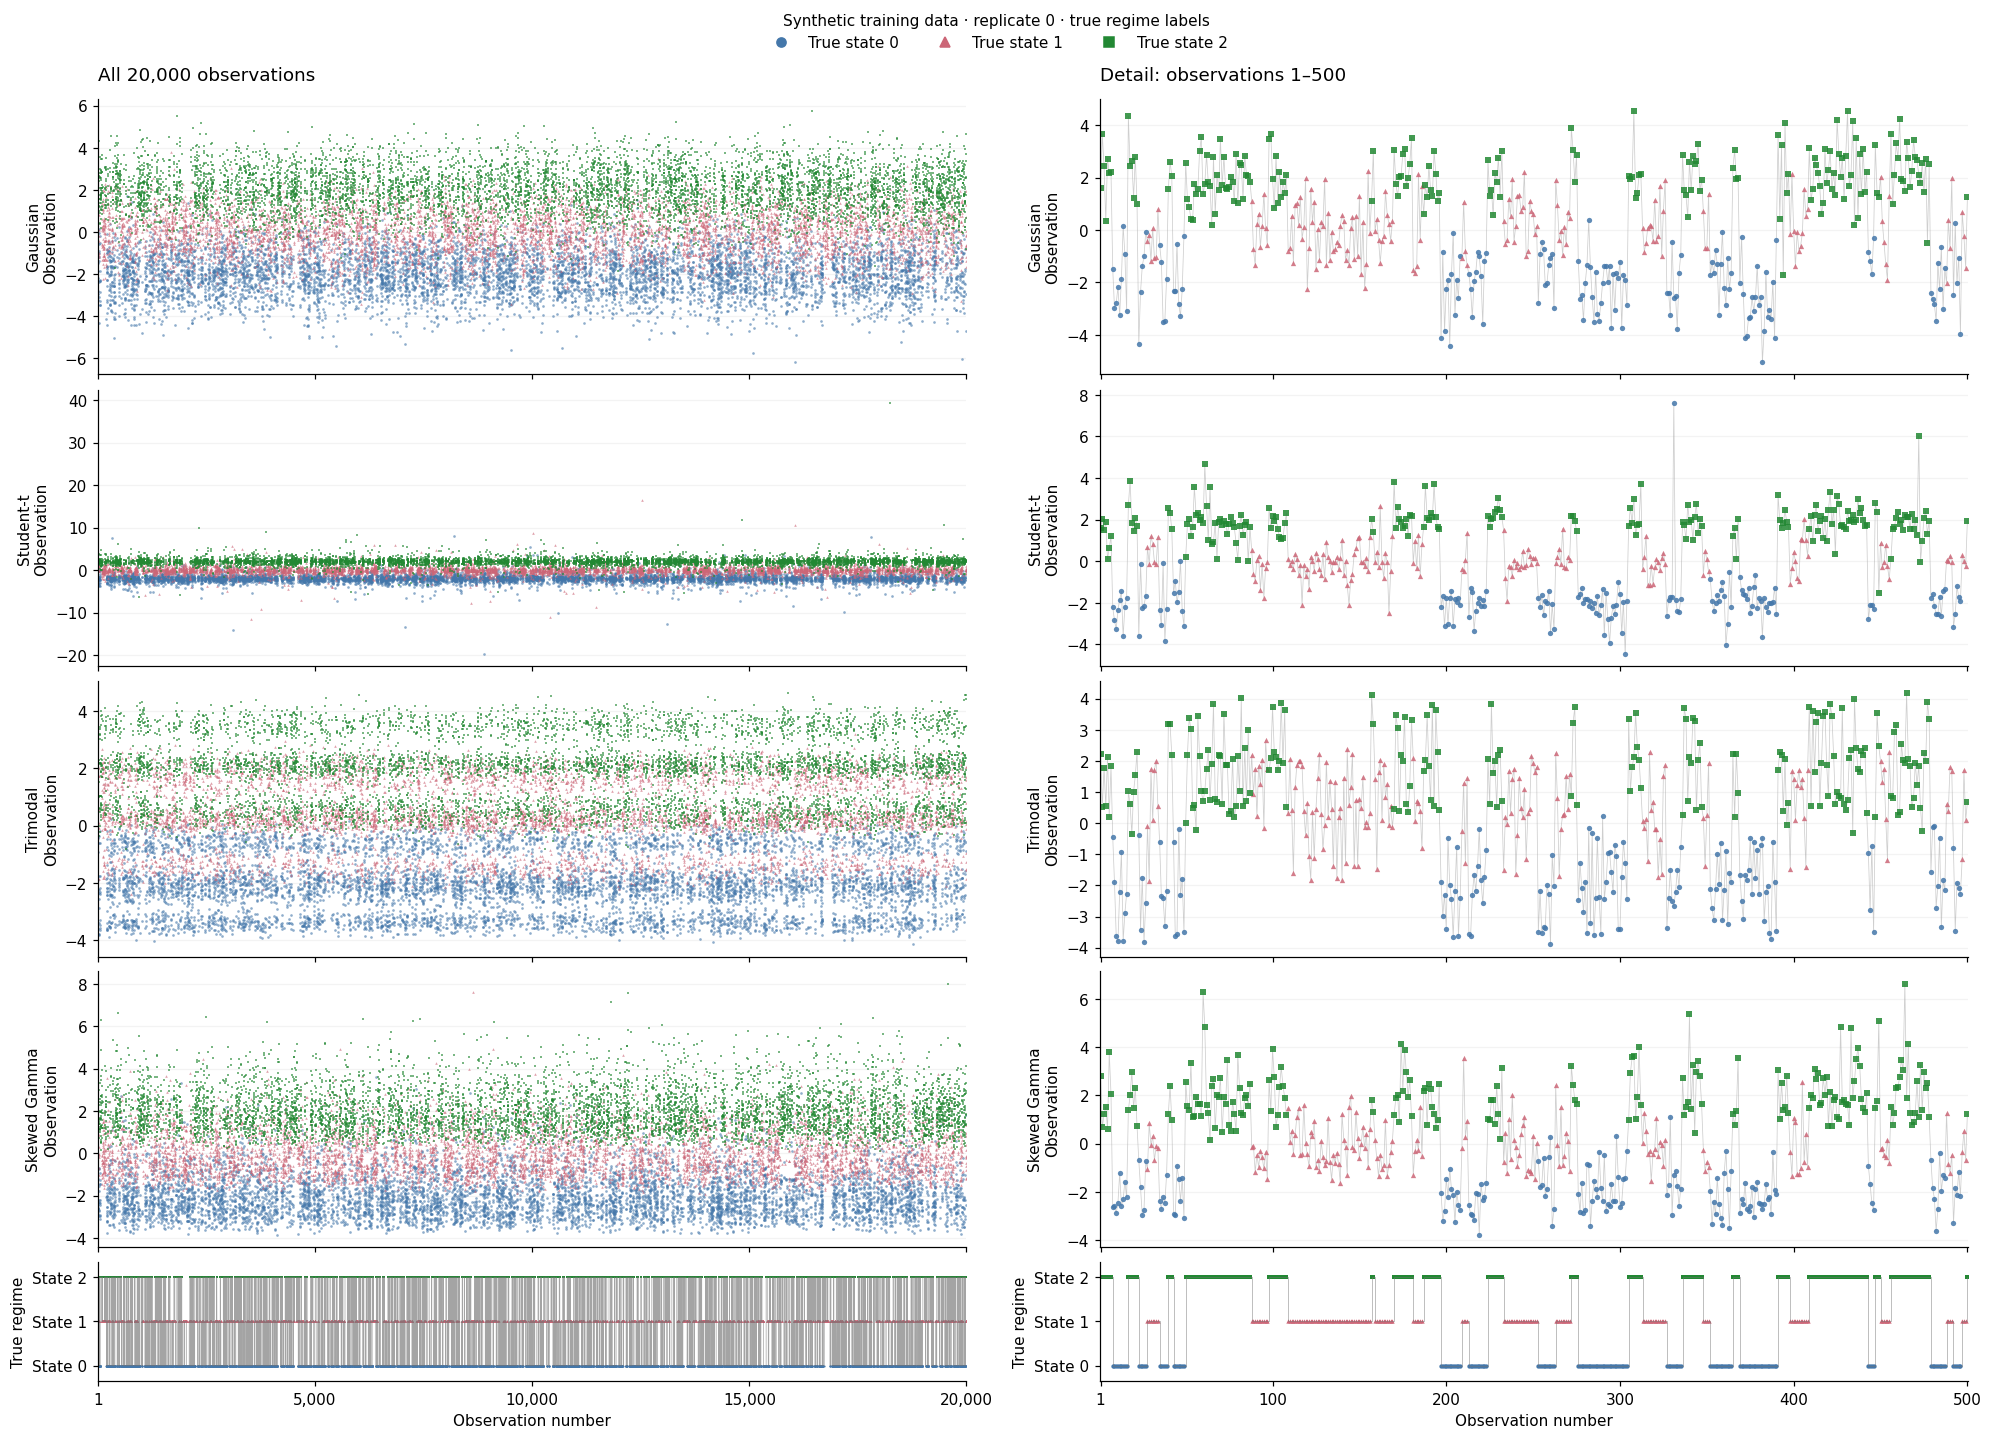

In [31]:
PLOT_REPLICATE = 0
PLOT_N = 20_000
PLOT_ZOOM_START = 0
PLOT_ZOOM_LENGTH = 500

from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter

if "datasets" not in globals():
    raise RuntimeError("The existing datasets must be in memory before plotting")
if not 0 <= PLOT_ZOOM_START < PLOT_N or PLOT_ZOOM_LENGTH < 1:
    raise ValueError("Choose a valid zoom offset and a positive window length")
plot_families = list(FAMILIES)
plot_frames = {}
for family in plot_families:
    key = (PLOT_REPLICATE, family)
    if key not in datasets:
        raise ValueError(f"No existing dataset for replicate {PLOT_REPLICATE}, {family}")
    frame = datasets[key]["train"].iloc[:PLOT_N]
    if len(frame) != PLOT_N:
        raise ValueError(f"{family} has fewer than {PLOT_N:,} training observations")
    if not np.isfinite(frame.x.to_numpy()).all():
        raise ValueError(f"{family} contains non-finite observations")
    plot_frames[family] = frame

plot_truth = plot_frames[plot_families[0]].state.to_numpy()
for family, frame in plot_frames.items():
    np.testing.assert_array_equal(frame.state.to_numpy(), plot_truth)
plot_states = np.unique(plot_truth)
if not np.array_equal(plot_states, np.array([0, 1, 2])):
    raise ValueError("This figure expects the experiment's three true states 0, 1, 2")
plot_state_colors = {0: "#4477AA", 1: "#CC6677", 2: "#228833"}
plot_state_markers = {0: "o", 1: "^", 2: "s"}
plot_zoom_stop = min(PLOT_N, PLOT_ZOOM_START + PLOT_ZOOM_LENGTH)
plot_windows = [(0, PLOT_N), (PLOT_ZOOM_START, plot_zoom_stop)]
plot_positions = np.arange(1, PLOT_N + 1)

regime_fig, regime_axes = plt.subplots(
    len(plot_families) + 1, 2,
    figsize=(18, 13), sharex="col", layout="constrained",
    gridspec_kw={"height_ratios": [3] * len(plot_families) + [1.3]},
)
for row, family in enumerate(plot_families):
    values = plot_frames[family].x.to_numpy()
    for column, (left, right) in enumerate(plot_windows):
        ax = regime_axes[row, column]
        positions = plot_positions[left:right]
        observations = values[left:right]
        truth = plot_truth[left:right]
        if column == 1:
            ax.plot(positions, observations, color="0.65", linewidth=.5, alpha=.55, zorder=1)
        for state in plot_states:
            mask = truth == state
            ax.scatter(
                positions[mask], observations[mask],
                c=plot_state_colors[state], marker=plot_state_markers[state],
                s=3 if column == 0 else 12,
                alpha=.6 if column == 0 else .85,
                linewidths=0, rasterized=True, zorder=2,
            )
        ax.set_ylabel(f"{family}\nObservation")
        ax.set_xlim(left + .5, right + .5)
        ax.grid(axis="y", alpha=.15)
        ax.grid(axis="x", visible=False)
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

regime_axes[0, 0].set_title(f"All {PLOT_N:,} observations", loc="left", pad=12)
regime_axes[0, 1].set_title(
    f"Detail: observations {PLOT_ZOOM_START + 1:,}–{plot_zoom_stop:,}", loc="left", pad=12
)
for column, (left, right) in enumerate(plot_windows):
    ax = regime_axes[-1, column]
    positions, truth = plot_positions[left:right], plot_truth[left:right]
    ax.step(positions, truth, where="post", color="0.45", linewidth=.45, alpha=.65)
    for state in plot_states:
        mask = truth == state
        ax.scatter(positions[mask], truth[mask], c=plot_state_colors[state],
                   marker=plot_state_markers[state], s=2 if column == 0 else 8,
                   linewidths=0, rasterized=True)
    ax.set(yticks=plot_states, yticklabels=[f"State {k}" for k in plot_states],
           ylim=(-.35, 2.35), xlabel="Observation number", ylabel="True regime")
    ax.grid(False)
    if column == 0:
        ax.set_xticks([1, 5_000, 10_000, 15_000, 20_000])
    else:
        ax.set_xticks(np.unique(np.linspace(left + 1, right, 6, dtype=int)))
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

regime_legend = [Line2D([], [], linestyle="none", marker=plot_state_markers[k],
                       color=plot_state_colors[k], markersize=6, label=f"True state {k}")
                 for k in plot_states]
regime_fig.legend(handles=regime_legend, loc="outside upper center", ncol=3,
                  frameon=False, title=f"Synthetic training data · replicate {PLOT_REPLICATE} · true regime labels")
plt.show()


## Fit the Gaussian HMM

For every family, training size, and replicate, fit `N_STARTS` independent initializations using observations alone. Choose the largest finite **training** likelihood. The test set never chooses an initialization.

The stopping tolerance is multiplied by the number of training observations because the trainer uses total log likelihood. This keeps the per-observation stopping rule consistent across sample sizes. Convergence, warnings, failures, likelihood decreases, and all training histories are recorded. Finite fits reaching the iteration limit remain eligible and are explicitly flagged.

After model selection, true **training** labels are used only to freeze the state permutation. The independent test sequence is then evaluated with that frozen mapping. Test accuracy and state log loss use whole-sequence (smoothed/offline) inference.

For each aligned state, emission KL is computed deterministically by numerical quadrature:

$$D_{KL}(p_k\|q_k)=\int p_k(x)\left[\log p_k(x)-\log q_k(x)\right]dx.$$

We also compute the **best-Gaussian KL floor** obtained by matching each true state's mean and variance. `excess_emission_kl = fitted_emission_kl - floor` separates unavoidable Gaussian-family shape mismatch from additional mismatch caused by the fitted HMM parameters/state organization.


In [5]:
attempt_rows, result_rows, parameter_rows = [], [], []
selected_models, evaluations = {}, {}
for family in FAMILIES:
    for n_train in TRAIN_SIZES:
        for replicate in range(N_REPLICATES):
            data = datasets[replicate, family]
            train_frame = data["train"].iloc[:n_train]
            X_train, y_train = train_frame[["x"]].to_numpy(), train_frame.state.to_numpy()
            X_test, y_test = data["test"][["x"]].to_numpy(), data["test"].state.to_numpy()
            candidates = []

            for start in range(N_STARTS):
                model_seed = seed_for("fit", replicate, start)
                record = {
                    "family": family, "n_train": n_train, "replicate": replicate,
                    "start": start, "seed": model_seed, "status": "failed", "selected": False,
                    "converged": False, "train_ll": np.nan, "error": None,
                }
                began = time.perf_counter()
                caught = []
                try:
                    with warnings.catch_warnings(record=True) as caught:
                        warnings.simplefilter("always")
                        model = HMM(
                            GaussianEmission(3, random_state=model_seed),
                            trainer=BaumWelchTrainer(
                                max_iter=MAX_ITER, tol=n_train * TOL_PER_OBSERVATION
                            ),
                        )
                        model.fit(X_train)
                    train_ll = float(model.history[-1])
                    if not np.isfinite(train_ll):
                        raise FloatingPointError("Nonfinite training likelihood")
                    record.update(
                        status="ok", converged=bool(model.trainer.converged),
                        iterations=model.trainer.n_iter, train_ll=train_ll,
                        final_gain_per_observation=(model.history[-1] - model.history[-2]) / n_train,
                        likelihood_decreases=int((np.diff(model.history) < -1e-6).sum()),
                        history=[float(v) for v in model.history],
                    )
                    candidates.append((train_ll, -start, model, record))
                except Exception as exc:
                    record["error"] = f"{type(exc).__name__}: {exc}"
                record["warnings"] = [str(w.message) for w in caught]
                record["fit_seconds"] = time.perf_counter() - began
                attempt_rows.append(record)

            if not candidates:
                result_rows.append({
                    "family": family, "n_train": n_train, "replicate": replicate,
                    "evaluation_status": "all_fits_failed",
                })
                continue

            _, _, model, chosen = max(candidates, key=lambda item: (item[0], item[1]))
            chosen["selected"] = True
            row = {
                "family": family, "n_train": n_train, "replicate": replicate,
                "selected_start": chosen["start"], "converged": chosen["converged"],
                "iterations": chosen["iterations"], "fit_seconds": chosen["fit_seconds"],
                "evaluation_status": "failed",
            }

            try:
                evaluator = SyntheticEvaluator(model).fit_alignment(X_train, y_train)
                evaluation = evaluator.evaluate(X_test, y_test, true_transitions=TRANSITIONS)
                order = np.argsort(evaluation.state_mapping)  # true state k -> corresponding learned state
                row.update(evaluation.metrics)
                row["test_nll"] = -row.pop("log_likelihood_per_observation")
                row["mean_rmse"] = float(np.sqrt(np.mean(
                    (model.emission.means[order, 0] - TRUE_MEANS[family])**2
                )))
                row["variance_rmse"] = float(np.sqrt(np.mean(
                    (model.emission.covariances[order, 0, 0] - TRUE_VARIANCES[family])**2
                )))

                for k in STATES:
                    learned_state = order[k]
                    fitted_mean = float(model.emission.means[learned_state, 0])
                    fitted_variance = float(model.emission.covariances[learned_state, 0, 0])
                    kl_value, kl_error = kl_true_to_gaussian(
                        family, k, fitted_mean, fitted_variance
                    )
                    row[f"kl_state_{k}"] = kl_value
                    row[f"kl_quad_error_state_{k}"] = kl_error
                    row[f"kl_floor_state_{k}"] = float(KL_FLOOR_BY_STATE[family][k])

                row["emission_kl"] = float(np.mean([row[f"kl_state_{k}"] for k in STATES]))
                row["emission_kl_floor"] = KL_FLOOR[family]
                row["excess_emission_kl"] = row["emission_kl"] - row["emission_kl_floor"]
                row["kl_quad_error_max"] = float(max(row[f"kl_quad_error_state_{k}"] for k in STATES))

                if not np.isfinite([
                    row["test_nll"], row["emission_kl"], row["excess_emission_kl"]
                ]).all():
                    raise FloatingPointError("Nonfinite evaluation score")
                # Numerical integration may produce tiny negative excess values around zero.
                if row["excess_emission_kl"] < -1e-6:
                    warnings.warn(
                        f"Emission KL fell below the theoretical Gaussian floor by "
                        f"{abs(row['excess_emission_kl']):.3e}; inspect quadrature/alignment."
                    )

                row["evaluation_status"] = "ok"
                key = (family, n_train, replicate)
                selected_models[key], evaluations[key] = model, evaluation
                parameter_rows.append({
                    "family": family, "n_train": n_train, "replicate": replicate,
                    "mapping_learned_to_true": evaluation.state_mapping.tolist(),
                    "training_alignment_counts": evaluator.alignment.training_counts.tolist(),
                    "aligned_means": model.emission.means[order].tolist(),
                    "aligned_variances": model.emission.covariances[order, 0, 0].tolist(),
                    "aligned_transitions": evaluation.aligned_transitions.tolist(),
                    "aligned_initial_probs": model.states.start[order].tolist(),
                })
            except Exception as exc:
                row["error"] = f"{type(exc).__name__}: {exc}"

            result_rows.append(row)
            print(
                f"{family:12s} N={n_train:5d}, replicate={replicate:02d}: "
                f"start={chosen['start']}, iterations={chosen['iterations']}, "
                f"converged={chosen['converged']}",
                flush=True,
            )

attempts = pd.DataFrame(attempt_rows)
results = pd.DataFrame(result_rows)
parameter_table = pd.DataFrame(parameter_rows)
assert len(attempts) == len(FAMILIES) * len(TRAIN_SIZES) * N_REPLICATES * N_STARTS
print(f"Finished: {len(attempts)} starts and {len(results)} selected-fit evaluations.")


Gaussian     N= 1000, replicate=00: start=3, iterations=33, converged=True
Gaussian     N= 1000, replicate=01: start=3, iterations=21, converged=True
Gaussian     N= 1000, replicate=02: start=4, iterations=26, converged=True
Gaussian     N= 1000, replicate=03: start=7, iterations=47, converged=True
Gaussian     N= 1000, replicate=04: start=5, iterations=45, converged=True
Gaussian     N= 1000, replicate=05: start=8, iterations=38, converged=True
Gaussian     N= 1000, replicate=06: start=1, iterations=31, converged=True
Gaussian     N= 1000, replicate=07: start=0, iterations=49, converged=True
Gaussian     N= 1000, replicate=08: start=1, iterations=23, converged=True
Gaussian     N= 1000, replicate=09: start=7, iterations=28, converged=True
Gaussian     N= 1000, replicate=10: start=5, iterations=26, converged=True
Gaussian     N= 1000, replicate=11: start=0, iterations=29, converged=True
Gaussian     N= 1000, replicate=12: start=5, iterations=32, converged=True
Gaussian     N= 1000, rep

## Evaluation Metrics

| Metric | Meaning |
|---|---|
| Test NLL / observation | How well the fitted HMM explains the held-out sequence |
| Emission KL | Quadrature $D_{KL}(p_{true,k}\|q_{fitted,k})$, averaged equally across states |
| Best-Gaussian KL floor | Unavoidable KL when the true emission is approximated by its moment-matched Gaussian | 
| Excess emission KL | Fitted KL minus that floor; extra mismatch beyond Gaussian-family shape limitation |
| Aligned accuracy | Correct test state labels using the mapping learned on training data | 
| ARI | Agreement of predicted and true state groupings |
| Transition RMSE | Error in aligned transition probabilities | 
| Capped state log loss (`state_log_loss`) | Mean negative log probability of the true state, floored at float64 epsilon (about 2.22e-16); each observation contributes at most about 36.04 nats |
| Capped fraction | Fraction of true-state posterior probabilities below that floor |
| Zero-probability fraction | Fraction of stored true-state posterior probabilities equal to zero, including numerical underflow |
| Mean / variance RMSE | Errors in aligned fitted emission moments |

KL uses **numerical quadrature**. The best-Gaussian floor provides a shape-only reference: if `excess_emission_kl` is near zero, the HMM's fitted Gaussian is close to the best Gaussian approximation for that true state; a large excess suggests additional state/parameter distortion under misspecification.

Raw test NLL also reflects the generating distribution's intrinsic entropy, so NLL learning curves are to be compared mainly **within a family** rather than ranking different families by raw NLL.

The table reports replicate means. The thin curves show individual replicate paths. Training sizes within a replicate share nested data and are therefore correlated; they must not be treated as independent repetitions.

In [23]:
metrics = [
    "test_nll", "emission_kl", "emission_kl_floor", "excess_emission_kl",
    "aligned_accuracy", "ari", "transition_rmse", "state_log_loss",
    "state_log_loss_capped_fraction", "state_zero_probability_fraction",
    "mean_rmse", "variance_rmse", "fit_seconds", "kl_quad_error_max",
]
successful = results[results.evaluation_status == "ok"]
if successful.empty:
    raise RuntimeError("No successful evaluations; inspect the attempts and results DataFrames")
missing_metrics = [metric for metric in metrics if metric not in successful.columns]
if missing_metrics:
    raise RuntimeError(
        f"The in-memory results are missing {missing_metrics}. "
        "Run 'Refresh evaluation metrics without retraining' above, then rerun this cell."
    )
summary = successful.groupby(["family", "n_train"])[metrics].agg(["mean", "std", "count"])
display(successful.groupby(["family", "n_train"])[metrics].mean().round(6))


test_nll  emission_kl  emission_kl_floor  \
family       n_train                                             
Gaussian     1000     1.714202     0.003028           0.000000   
             5000     1.710734     0.000801           0.000000   
             20000    1.710591     0.000350           0.000000   
Skewed Gamma 1000     1.575549     2.309042           0.088679   
             5000     1.556476     2.060838           0.088679   
             20000    1.556159     2.152905           0.088679   
Student-t    1000     1.652000     0.575838           0.375897   
             5000     1.661246     0.897725           0.375897   
             20000    1.650766     0.835451           0.375897   
Trimodal     1000     1.814911     2.139955           0.294603   
             5000     1.801614     0.295063           0.294603   
             20000    1.801042     0.294893           0.294603   

                      excess_emission_kl  aligned_accuracy       ari  \
family       n_train                                                   
Gaussian     1000               0.003028          0.940600  0.833944   
             5000               0.000801          0.941533  0.836686   
             20000              0.000350          0.942200  0.838288   
Skewed Gamma 1000               2.220363          0.864733  0.652617   
             5000               1.972159          0.872467  0.667799   
             20000              2.064225          0.871600  0.665994   
Student-t    1000               0.199940          0.959400  0.884353   
             5000               0.521827          0.754333  0.626075   
             20000              0.459553          0.827800  0.699838   
Trimodal     1000               1.845352          0.794733  0.611604   
             5000               0.000460          0.895267  0.719753   
             20000              0.000290          0.893867  0.715832   

                      transition_rmse  state_log_loss  \
family       n_train                                    
Gaussian     1000            0.013205        0.160953   
             5000            0.004758        0.158359   
             20000           0.004044        0.156201   
Skewed Gamma 1000            0.127390        1.759231   
             5000            0.104865        1.570526   
             20000           0.108755        1.604503   
Student-t    1000            0.018890        0.247179   
             5000            0.244202        1.282507   
             20000           0.128383        0.991283   
Trimodal     1000            0.134929        2.347855   
             5000            0.006463        0.248754   
             20000           0.005438        0.251661   

                      state_log_loss_capped_fraction  \
family       n_train                                   
Gaussian     1000                           0.000133   
             5000                           0.000133   
             20000                          0.000133   
Skewed Gamma 1000                           0.018933   
             5000                           0.016067   
             20000                          0.015933   
Student-t    1000                           0.001333   
             5000                           0.001467   
             20000                          0.001533   
Trimodal     1000                           0.029467   
             5000                           0.000133   
             20000                          0.000200   

                      state_zero_probability_fraction  mean_rmse  \
family       n_train                                               
Gaussian     1000                            0.000000   0.041685   
             5000                            0.000000   0.019793   
             20000                           0.000000   0.016126   
Skewed Gamma 1000                            0.000067   0.380706   
             5000                            0.000067   0.341392   
             20000          

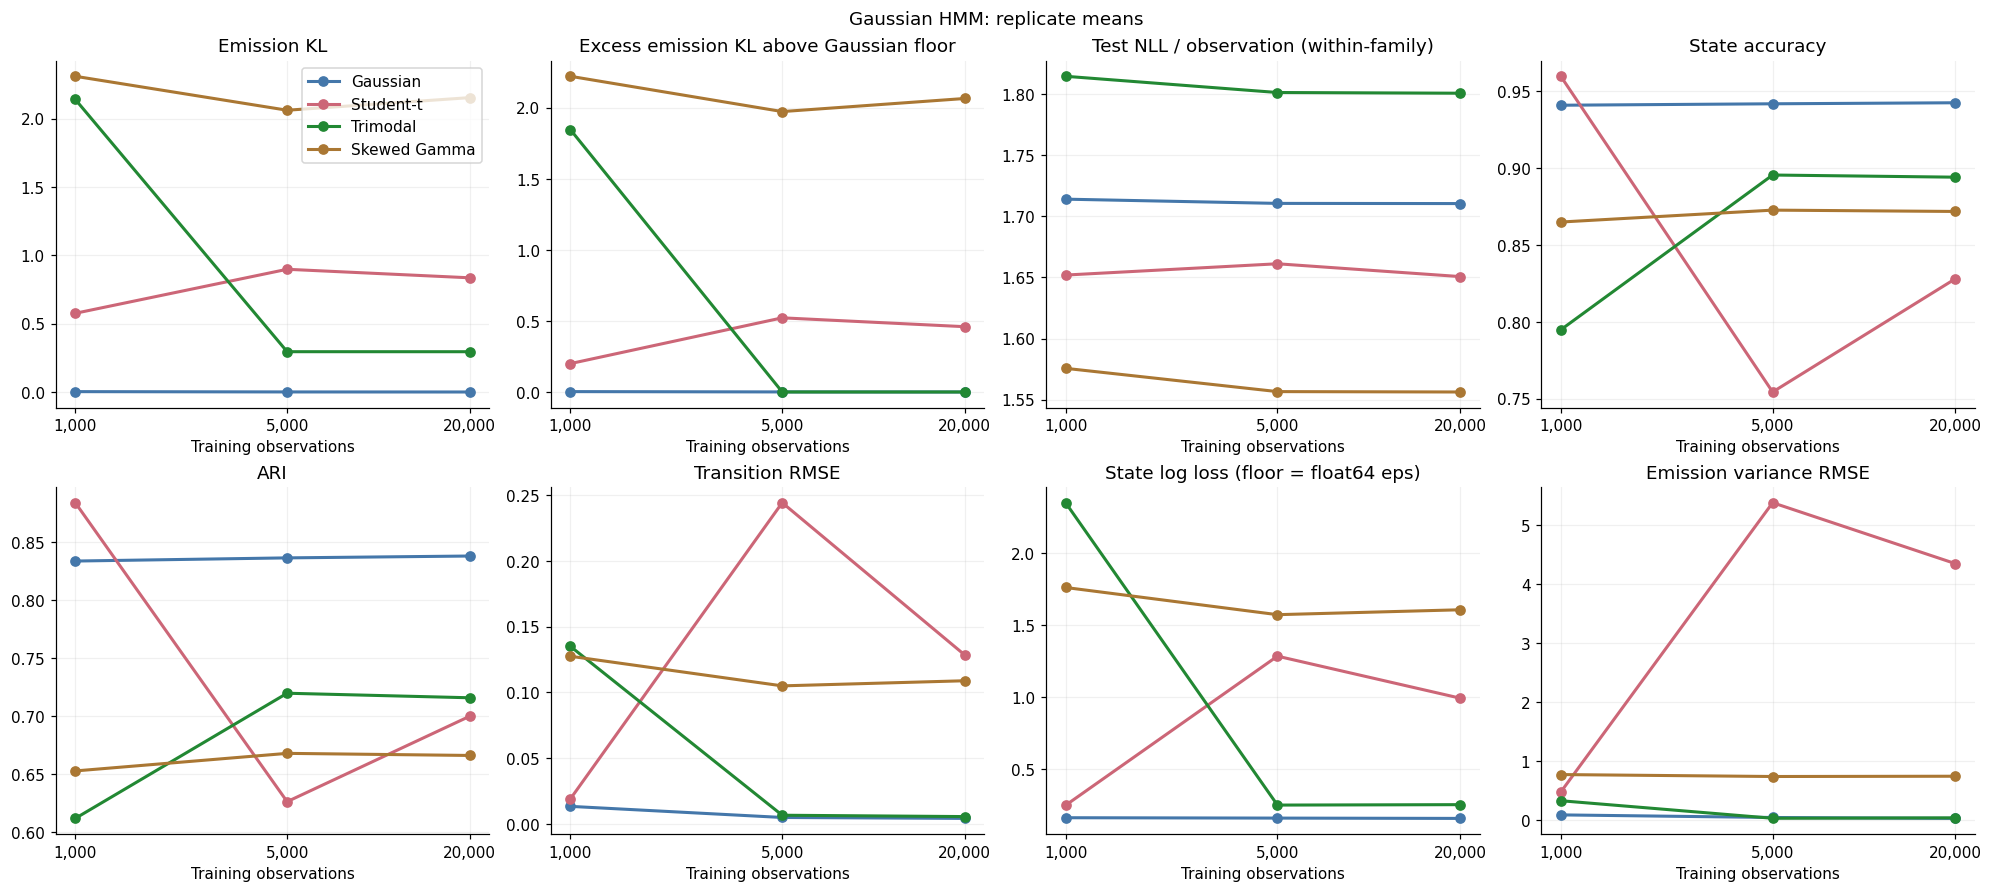

In [27]:
plot_metrics = [
    ("emission_kl", "Emission KL"),
    ("excess_emission_kl", "Excess emission KL above Gaussian floor"),
    ("test_nll", "Test NLL / observation (within-family)"),
    ("aligned_accuracy", "State accuracy"),
    ("ari", "ARI"),
    ("transition_rmse", "Transition RMSE"),
    ("state_log_loss", "State log loss (floor = float64 eps)"),
    ("variance_rmse", "Emission variance RMSE"),
]
fig, axes = plt.subplots(2, 4, figsize=(18, 8), layout="constrained")
for ax, (metric, title) in zip(axes.flat, plot_metrics):
    for family in FAMILIES:
        part = successful[successful.family == family]
        means = part.groupby("n_train")[metric].mean()
        ax.plot(means.index, means.values, marker="o", color=COLORS[family], linewidth=2, label=family)
    ax.set_xscale("log")
    ax.set_xticks(TRAIN_SIZES, [f"{n:,}" for n in TRAIN_SIZES])
    ax.minorticks_off()
    ax.set(title=title, xlabel="Training observations")
axes.flat[0].legend()
fig.suptitle("Gaussian HMM: replicate means")
plt.show()


Using the predetermined example **replicate 0, N=20,000**, rather than selecting an especially favorable test outcome, we can plot the emissions below.

The table underneath reports both each state's fitted-emission KL and the corresponding **best-Gaussian floor**. A large gap between them means the fitted HMM is doing more than simply replacing the true distribution with its best Gaussian approximation.


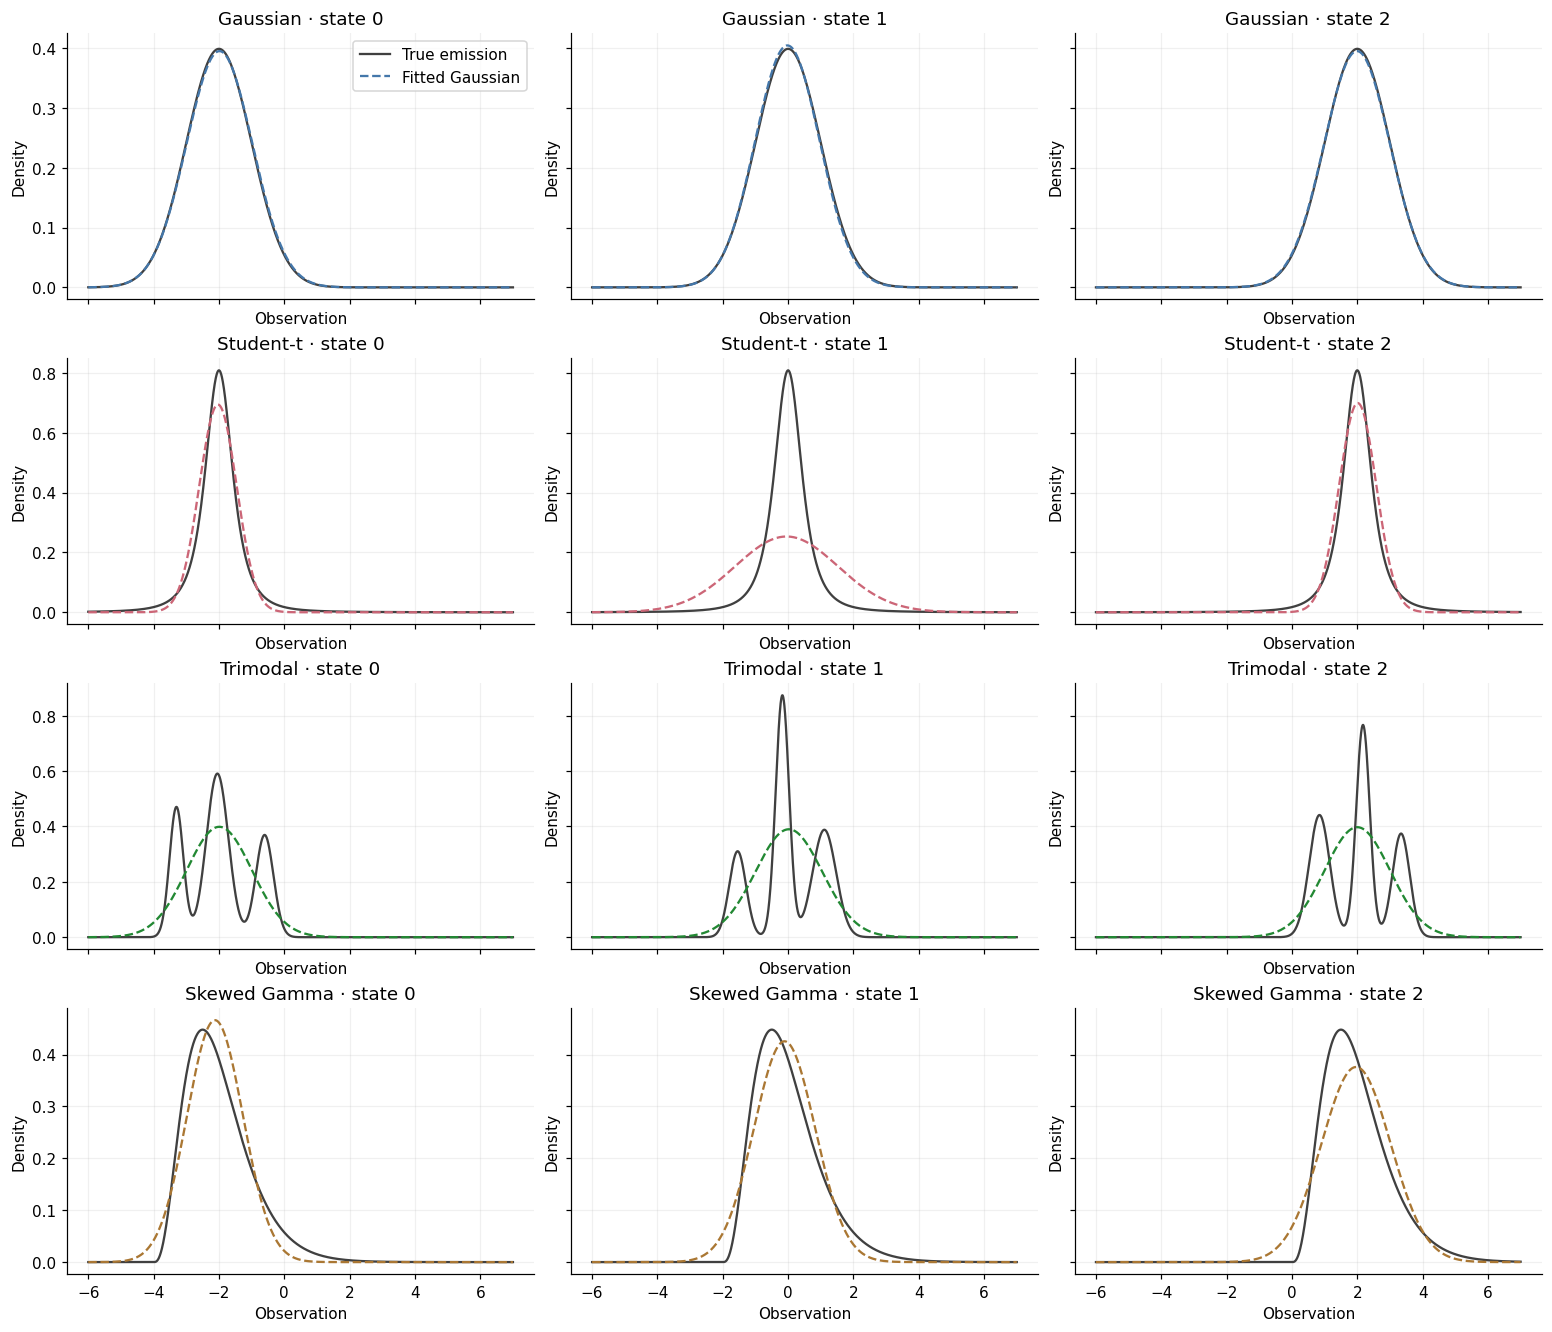

kl_state_0  kl_state_1  kl_state_2  kl_floor_state_0  \
family       n_train                                                         
Gaussian     1000       0.003348    0.005117    0.004050          0.000000   
             5000       0.000703    0.001145    0.000938          0.000000   
             20000      0.000319    0.000260    0.000181          0.000000   
Skewed Gamma 1000       0.152768    0.122590    0.098585          0.088679   
             5000       0.128825    0.106423    0.093716          0.088679   
             20000      0.120679    0.104521    0.093145          0.088679   
Student-t    1000       0.678887    0.906775    0.601035          0.375897   
             5000       0.789724    0.868688    0.625129          0.375897   
             20000      0.854717    0.817930    0.723706          0.375897   
Trimodal     1000       0.264549    0.325215    0.307950          0.259079   
             5000       0.259635    0.321401    0.305509          0.259079   
             20000      0.259238    0.320998    0.304886          0.259079   

                      kl_floor_state_1  kl_floor_state_2  
family       n_train                                      
Gaussian     1000             0.000000          0.000000  
             5000             0.000000          0.000000  
             20000            0.000000          0.000000  
Skewed Gamma 1000             0.088679          0.088679  
             5000             0.088679          0.088679  
             20000            0.088679          0.088679  
Student-t    1000             0.375897          0.375897  
             5000             0.375897          0.375897  
             20000            0.375897          0.375897  
Trimodal     1000             0.320231          0.304501  
             5000             0.320231          0.304501  
             20000            0.320231          0.304501

In [8]:
fig, axes = plt.subplots(len(FAMILIES), 3, figsize=(14, 12), sharex=True, sharey="row", layout="constrained")
for row, family in enumerate(FAMILIES):
    key = (family, max(TRAIN_SIZES), 0)
    if key not in selected_models:
        for ax in axes[row]:
            ax.text(.5, .5, "Fit/evaluation unavailable", ha="center", transform=ax.transAxes)
        continue
    model = selected_models[key]
    order = np.argsort(evaluations[key].state_mapping)
    learned = model.emission.log_prob(x[:, None])[:, order]
    for k, ax in enumerate(axes[row]):
        ax.plot(x, np.exp(true_log_density(family, k, x)), color=".25", label="True emission")
        ax.plot(x, np.exp(learned[:, k]), "--", color=COLORS[family], label="Fitted Gaussian")
        ax.set(title=f"{family} · state {k}", xlabel="Observation", ylabel="Density")
axes[0, 0].legend()
plt.show()

state_kl_cols = [f"kl_state_{k}" for k in STATES]
floor_cols = [f"kl_floor_state_{k}" for k in STATES]
display(successful.groupby(["family", "n_train"])[state_kl_cols + floor_cols].mean().round(6))


## Checking fitting reliability


In [9]:
diagnostics = attempts.assign(failed=attempts.status != "ok").groupby(["family", "n_train"]).agg(
    starts=("status", "size"),
    failures=("failed", "sum"),
    converged_starts=("converged", "sum"),
    total_fit_seconds=("fit_seconds", "sum"),
    mean_iterations=("iterations", "mean"),
)
selected_convergence = results.groupby(["family", "n_train"])["converged"].agg(["sum", "count"])
diagnostics["selected_converged"] = selected_convergence["sum"]
diagnostics["selected_fits"] = selected_convergence["count"]
display(diagnostics.round(2))

variability = attempts[attempts.status == "ok"].groupby(
    ["family", "n_train", "replicate"]
).train_ll.agg(["min", "max"])
variability["range_per_observation"] = (
    (variability["max"] - variability["min"]) /
    variability.index.get_level_values("n_train")
)
display(variability.groupby(["family", "n_train"])[["range_per_observation"]].mean().round(6))

warning_series = attempts["warnings"].explode().dropna()
warning_series = warning_series[warning_series.astype(str).str.len() > 0]
if warning_series.empty:
    print("Fit warnings: none")
else:
    display(warning_series.value_counts().rename_axis("warning").to_frame("count"))

print("Fit failures:", int((attempts.status != "ok").sum()))
print("Evaluation outcomes:", results.evaluation_status.value_counts().to_dict())
print(f"Selected fits converged: {int(results.converged.fillna(False).sum())}/{len(results)}")
print("Likelihood decreases > 1e-6:", int(attempts.likelihood_decreases.fillna(0).sum()))
print("Maximum quadrature error estimate:", successful.kl_quad_error_max.max())


starts  failures  converged_starts  total_fit_seconds  \
family       n_train                                                          
Gaussian     1000        200         0               200              61.05   
             5000        200         0               200             290.38   
             20000       200         0               200            1134.17   
Skewed Gamma 1000        200         0               200              71.21   
             5000        200         0               200             295.38   
             20000       200         0               200            1116.36   
Student-t    1000        200         0               200              75.88   
             5000        200         0               200             403.07   
             20000       200         0               200            1675.79   
Trimodal     1000        200         0               200              64.43   
             5000        200         0               200             273.56   
             20000       200         0               200            1083.51   

                      mean_iterations  selected_converged  selected_fits  
family       n_train                                                      
Gaussian     1000               33.57                  20             20  
             5000               32.28                  20             20  
             20000              32.19                  20             20  
Skewed Gamma 1000               38.66                  20             20  
             5000               33.22                  20             20  
             20000              31.82                  20             20  
Student-t    1000               42.20                  20             20  
             5000               45.70                  20             20  
             20000              47.88                  20             20  
Trimodal     1000               35.31                  20             20  
             5000               30.78                  20             20  
             20000              30.64                  20             20

range_per_observation
family       n_train                       
Gaussian     1000                  0.022490
             5000                  0.015006
             20000                 0.000001
Skewed Gamma 1000                  0.035342
             5000                  0.040757
             20000                 0.030052
Student-t    1000                  0.164344
             5000                  0.101538
             20000                 0.067917
Trimodal     1000                  0.006825
             5000                  0.000032
             20000                 0.022360

Fit warnings: none
Fit failures: 0
Evaluation outcomes: {'ok': 240}
Selected fits converged: 240/240
Likelihood decreases > 1e-6: 0
Maximum quadrature error estimate: 2.037426227730066e-09


## Save the experiment artifacts

In [25]:
from datetime import datetime, timezone
import tempfile

if manifest.get("state_log_loss_definition") != "Mean negative log(max(true-state posterior, float64 epsilon)); capped":
    raise RuntimeError("Refresh the existing state log loss before exporting this run")

artifact_root = project_root / "data/synthetic/gaussian_synthetic_experiments"
artifact_root.mkdir(parents=True, exist_ok=True)
run_dir = Path(tempfile.mkdtemp(
    prefix=datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ-"),
    dir=artifact_root,
))

def json_safe(value):
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if isinstance(value, np.generic):
        return json_safe(value.item())
    if isinstance(value, float) and not np.isfinite(value):
        return "NaN" if np.isnan(value) else ("Infinity" if value > 0 else "-Infinity")
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    return value

def save_json(filename, value):
    (run_dir / filename).write_text(
        json.dumps(json_safe(value), indent=2, allow_nan=False) + "\n",
        encoding="utf-8",
    )

save_json("manifest.json", manifest)
for name, frame in (
    ("results", results), ("attempts", attempts),
    ("parameters", parameter_table), ("coverage", coverage),
):
    save_json(f"{name}.json", frame.to_dict(orient="records"))
    frame.to_csv(run_dir / f"{name}.csv", index=False)

model_dir = run_dir / "models"
model_dir.mkdir()
model_index = []
for number, (key, fitted_model) in enumerate(selected_models.items()):
    family, n_train, replicate = key
    filename = f"models/model_{number:04d}.npz"
    np.savez_compressed(
        run_dir / filename,
        means=fitted_model.emission.means,
        covariances=fitted_model.emission.covariances,
        start=fitted_model.states.start,
        transitions=fitted_model.states.transitions,
        mapping_learned_to_true=evaluations[key].state_mapping,
        min_variance=np.array(fitted_model.emission.min_variance),
    )
    model_index.append({"family": family, "n_train": n_train,
                        "replicate": replicate, "file": filename})
save_json("model_index.json", model_index)

data_dir = run_dir / "datasets"
data_dir.mkdir()
data_index = []
for number, ((replicate, family), splits) in enumerate(datasets.items()):
    filename = f"datasets/dataset_{number:04d}.npz"
    arrays = {f"{split}__{column}": frame[column].to_numpy()
              for split, frame in splits.items() for column in frame.columns}
    np.savez_compressed(run_dir / filename, **arrays)
    data_index.append({"family": family, "replicate": replicate, "file": filename})
save_json("dataset_index.json", data_index)
print(f"Saved experiment artifacts to {run_dir}")


Saved experiment artifacts to /Users/leoyang/Desktop/School/CSCD94/data/synthetic/gaussian_synthetic_experiments/20261001T031118Z-57k1g_1e
